# Assignment: week 2

The objectives of this assignment are:

1. to try out different model architectures
2. to experiment with different kinds of regularization

In [480]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

In [481]:
import matplotlib.pyplot as plt
import numpy as np
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, BatchNormalization, Activation
from keras.optimizers import Adam, SGD
from keras.callbacks import EarlyStopping
from keras.datasets import california_housing
from keras.regularizers import l2

## Data preprocessing

First I extracted the training and validation data and split the test data to be used after training.

In [482]:
(inputs, targets), (x_test, y_test) = california_housing.load_data(version='large', 
                                        test_split=0.2,
                                        seed=8669)

print(inputs.shape, targets.shape)
print(x_test.shape, y_test.shape)

(16512, 8) (16512,)
(4128, 8) (4128,)


Splitting train / val data `80/20`

In [483]:
train_val_split_idx = int(len(inputs) * 0.8)

print(f"Length of the dataset: {len(inputs)}")
print(f"Train split size: {train_val_split_idx}")
print(f"Validation split size: {len(inputs) - train_val_split_idx}")

Length of the dataset: 16512
Train split size: 13209
Validation split size: 3303


In [484]:
x_train = inputs[:train_val_split_idx]
y_train = targets[:train_val_split_idx]
x_val = inputs[train_val_split_idx:]
y_val = targets[train_val_split_idx:]

print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)

(13209, 8) (13209,)
(3303, 8) (3303,)


Next I shuffled the data, which allows the model to train better and more realistically with it.

In [485]:
train_idx = np.random.permutation(len(x_train))
x_train = x_train[train_idx]
y_train = y_train[train_idx]

val_idx = np.random.permutation(len(x_val))
x_val = x_val[val_idx]
y_val = y_val[val_idx]

test_idx = np.random.permutation(len(x_test))
x_test = x_test[test_idx]
y_test = y_test[test_idx]

Applying standardization to the input variables.

Scaling target variables to obtain values on the order of unity.

In [ ]:
mean = x_train.mean(axis=0)
std = x_train.std(axis=0)

x_train -= mean
x_train /= std
x_test -= mean
x_test /= std
x_val -= mean
x_val /= std

y_train /= 1e5
y_test /= 1e5
y_val /= 1e5

## Modeling

Building of the model using different regularization methods to fight overfitting.

Models were tested with a large mix of:
- Different amounts and types of hidden layers
- BatchNormalization
- Different amounts of Dropouts
    - in many different positions
- Couple tests with L2 Regularization, but with no noticeable differences compared to the above

In [488]:
model = Sequential([
    Input(shape=(8,)),

    Dense(64),
    BatchNormalization(),
    Activation('relu'),

    Dense(32),
    Activation('relu'),
    Dropout(0.2),

    Dense(1)
])

Model was tested with both Adam and SGD as its optimizers.
- Adam showed more promise when adding regularization
    - especially when lowering the learning rate!
- SGD performed better when testing for models with clear overfitting
    - which means finding the overfitting model was harder

In [489]:
opt = Adam(learning_rate=0.0005)
# opt = SGD()
model.compile(optimizer=opt, loss='mse', metrics=['mae'])

EarlyStopping was used for fighting overfitting and restoring best weights after the training was complete.

In [490]:
es_callback = EarlyStopping(monitor='val_mae' ,patience=10, restore_best_weights=True)

history = model.fit(x_train, y_train, validation_data=(x_val, y_val),
          epochs=100,
          batch_size=32,
          callbacks=[es_callback]
          )

Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.1935 - mae: 0.8019 - val_loss: 0.6377 - val_mae: 0.5700
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6824 - mae: 0.6077 - val_loss: 0.4419 - val_mae: 0.4705
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5817 - mae: 0.5560 - val_loss: 0.4385 - val_mae: 0.4586
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5593 - mae: 0.5398 - val_loss: 0.4060 - val_mae: 0.4376
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5192 - mae: 0.5205 - val_loss: 0.3883 - val_mae: 0.4540
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5052 - mae: 0.5122 - val_loss: 0.3574 - val_mae: 0.4200
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4924 - mae: 0.5045 - val_loss: 0.3862 - val_mae: 0.4222
Epoch 8/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4793 - mae: 0.4953 - val_loss: 0.3570 - val_mae: 0.4112
Epoch 9/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

Let's evaluate the models performance using ``MSE`` and ``MAE`` with unseen data.

In [496]:
test_mse, test_mae = model.evaluate(x_test, y_test, verbose=0)
print(f"Test MSE: {test_mse:.6f}")
print(f"Test MAE: {test_mae:.6f}")

print(f"\nTest MAE ≈ ${test_mae * 1e5:,.0f}")

Test MSE: 0.321799
Test MAE: 0.375563

Test MAE ≈ $37,556


We can see that the model predicts a Mean Absolute Error of about $37k dollars using the `x_test` and `y_test` datasets, which is a good result considering the simplicity of the model.

### Plotting the results

Graph of models improvement on `train loss` and `val loss` over epochs.

Text(0, 0.5, 'Loss')

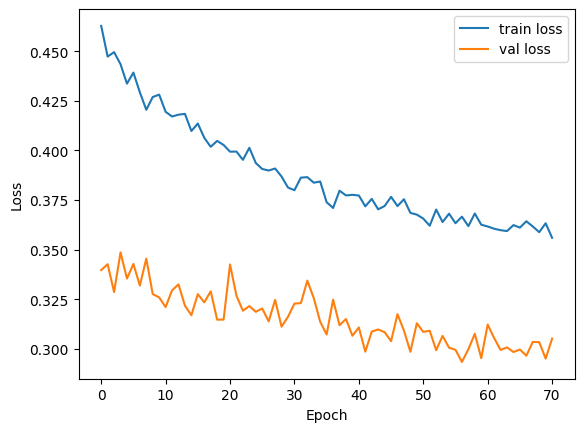

In [491]:
plt.plot(history.history['loss'][10:], label='train loss')
plt.plot(history.history['val_loss'][10:], label='val loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')

Graph of models improvement on `train MAE` and `val MAE` over epochs.

Text(0, 0.5, 'Mean absolute error (in 100000 $)')

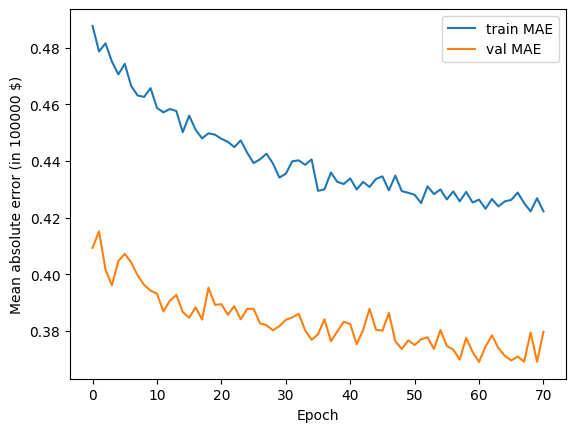

In [492]:
plt.plot(history.history['mae'][10:], label='train MAE')
plt.plot(history.history['val_mae'][10:], label='val MAE')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Mean absolute error (in 100000 $)')

Both of the graphs show no clear signs of overfitting. The validation data on both graphs keeps going down steadily alongside the training data.

### Results of monitoring models and overfitting

What I noticed impacting overfitting the most were:
- Large amounts of epochs
- Large amounts of hidden layers
- Hidden layers with large amounts of units (started overfitting a lot with Dense(128))
- Raising the optimizers learning rate too much

Below are models with clear signs of overfitting, which were a direct result of the aforementioned findings.

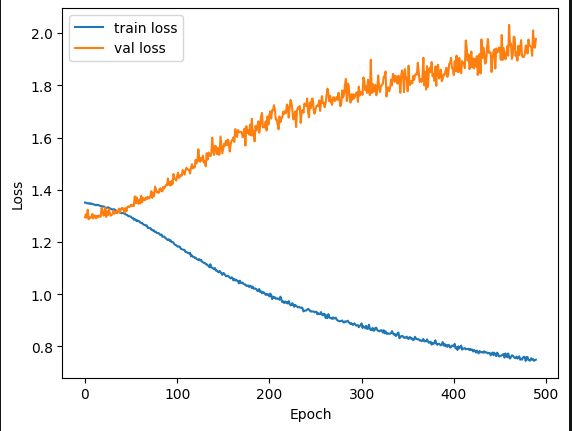
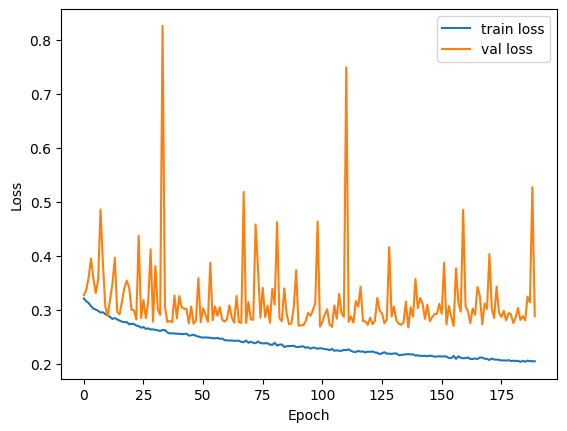